(sec:environment)=
# Environment

VeloxChem implements both implicit (CPCM and SMD) and explicit (polarizable embedding) solvation models. 

## Implicit solvation

Implicit solvation models describe the effect of a surrounding liquid environment by replacing the explicit solvent molecules with a continuous dielectric medium that interacts self‑consistently with the electronic structure of the solute. {cite}`Tomasi2005`

A separation is made between equilibrium and non-equilibrium solvation. In the former case, the timescale is such that both nuclear and electronic relaxations take place in the environment, such as in molecular structure optimizations. In the latter case, only electrons are fully equilibrated with the time-dependent solute charge density, such as in UV/vis spectrum simulations. 

(sec:cpcm)=
### CPCM

In the conductor‑like polarizable continuum model (CPCM), the solute is placed inside a cavity defined by its molecular surface, and the reaction field is obtained by solving surface‑charge equations that approximate the dielectric screening of a perfect conductor and are subsequently scaled to represent the desired solvent permittivity.

VeloxChem implements the CPCM model for:

- SCF energies
- gradients (structure optimizations)
- linear response (UV/vis spectra and more)

**Python script**

In [ ]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("ammonia")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_drv.solvation_model = "cpcm"
scf_results = scf_drv.compute(molecule, basis)

rsp_drv = vlx.LinearResponseEigenSolver()
rsp_drv.nstates = 10
rsp_results = rsp_drv.compute(molecule, basis, scf_results)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_results = opt_drv.compute(molecule, basis, scf_results)

In CPCM, the induced charge density on the cavity (due to the presence of the solute) is represented on a surface grid and discretized as Gaussian charges centred at the grid points. The converged grid charges can be visualized using the CPCM driver.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

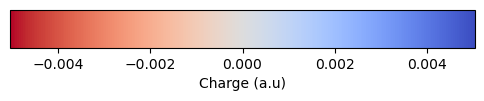

In [3]:
opt_molecule = opt_results["final_molecule"]
scf_drv.cpcm_drv.visualize_cpcm_charges(opt_molecule)

:::{note}
Water is the default solvent. For other solvents, set the dielectric constant:
:::{code}
scf_drv.cpcm_epsilon = 24.5  # ethanol
:::
:::

**Text file**

:::{code}
@jobs
task: scf
@end

@method settings
basis: def2-svp
xcfun: b3lyp
solvation model: cpcm
cpcm epsilon : 78.39
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

(sec:smd)=
### SMD

The solvation model based on density (SMD) combines a self‑consistent reaction‑field description of the electrostatic polarization with empirically parametrized terms for cavitation, dispersion, and solvent–solute interactions based on the solute’s electron density, enabling accurate free‑energy predictions across a wide range of solvents. For further details, see {cite}`Marenich2009`.

In Veloxchem, the electrostatic contribution is determined using the CPCM model.

**Python script**

In [ ]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("methanol")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()

scf_drv.solvation_model = "smd"
scf_drv.smd_solvent = "water"

scf_results = scf_drv.compute(molecule, basis)

**Text file**

:::{code}
@jobs
task: scf
@end

@method settings
basis: def2-svp
xcfun: b3lyp
solvation model: smd
smd solvent : water
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

(sec:explicit_solvation)=
## Explicit solvation

An explicit representation of the environment is available with:

- Polarizable embedding (PE), where molecules in the environment are represented by site charges and polarizabilities.

- Non-polarizable embedding (NPE), where the environment is represented by point charges only.

A PDB, containing one or more structures, can be passed to the `EnsembleParser`. In this step, the PE and NPE cutoffs (in Å) are selected:

In [ ]:
import veloxchem as vlx

ens_parser = vlx.EnsembleParser()

ensemble = ens_parser.structures(
    trajectory_file = "../input_files/alpha-helix-acetone-water.pdb",
    qm_region = "resname LIG or (water and around 3.0 (resname LIG))",
    env_region = "protein or water or resname NA CL",
    pe_cutoff = 6.0,
    npe_cutoff = 10.0,
)

Key parameters are the following:

- `qm_region`: MDAnalysis selection string that defines QM region. In the above example, all atoms in the LIG residue, as well as water molecules within 3 Å from the center of mass of LIG, will be treated as QM.
- `qm_charge`: charge of the QM region
- `env_region`: MDAnalysis selection string that defines environment. In the above example, all atoms in the protein, water and Na$^{+}$ and Cl$^{-}$ ions will be considered. In the environment region:
    - All residues within a `pe_cutoff` from the center of mass of the QM region will be treated with PE.
    - All residues within a `npe_cutoff` from the center of mass of the QM region will be treated with NPE.

The number of residues treated with PE and NPE can be accessed as follows:

In [2]:
print("number residues PE = ", ensemble[0]["number_residues_pe"])
print("number residues NPE = ", ensemble[0]["number_residues_npe"])

number residues PE =  60
number residues NPE =  176


Once the environment has been defined, the environment models can be selected with the `set_env_models` method of the `EnsembleDriver`:

In [3]:
ens_drv = vlx.EnsembleDriver()

ens_drv.set_env_models(
    pe_model=["CP3", "SEP"],
    npe_model=["ff19sb", "tip3p"],
)

VeloxChem supports the following environment models for PE and NPE:
- PE: `CP3` {cite}`Reinholdt2020` for proteins, and `SEP` {cite}`Beerepoot2016` for common polar and non-polar solvent molecules and ions.
- NPE: `ff19sb` {cite}`Tian2020` for proteins, and `tip3p` {cite}`Jorgensen1983` for water.

:::{image} ../images/models-no-cite.png
:align: center
:width: 600px
:::

The SCF calculations can be automated by passing `scf_options` and, optionally, `property_options` to the `compute` method:

In [ ]:
scf_options = {
   "scf_type": "restricted",
   "conv_thresh": 1.0e-6,
   "max_iter": 150,
   "xcfun": "cam-b3lyp",
   "grid_level": 4,
}

property_options = {
    "property": "absorption",
    "nstates": 5,
    "nto": True,
}

In [ ]:
results = ens_drv.compute(
   ensemble,
   basis_set = "def2-svp",
   scf_options = scf_options,
   property_options = property_options,
)

In some situations, for example when preparing input files for running on a cluster, it is convenient to use the `write_pot_files` method to generate the potential files:


In [ ]:
ens_drv.write_pot_files(ensemble)

**Text file**

:::{code}
@jobs
task: scf
@end

@method settings
xcfun: cam-b3lyp
basis: def2-svp
potfile: pe_frame_000000.pot
@end

@molecule
charge: 0
multiplicity: 1
xyz:
H  22.62173653  22.99879456  21.90585327
C  22.59173584  22.10879517  22.5258522
H  21.75173569  21.4787941   22.22585297
H  23.49173546  21.51879501  22.33585358
C  22.23173523  22.48879433  23.99585342
O  21.51173592  21.73879433  24.68585205
C  22.73173523  23.7987957   24.55585289
H  22.00173569  24.57879448  24.37585258
H  22.84173584  23.69879532  25.63585281
H  23.74173546  24.11879539  24.29585266
H  22.77173615  27.41879463  24.01585388
O  26.12173653  22.63879585  23.38585281
O  24.85173607  26.55879402  24.4158535
H  25.37173653  25.93879509  24.92585373
H  25.39173698  25.57879448  22.87585258
H  25.46173668  24.18879509  22.29585266
H  26.1117363   20.74879456  23.14585304
@end
:::


The potential file named `pe_frame_000000.pot` in this example takes the following form: [`pe_frame_000000.pot`](../input_files/pe_frame_000000.pot)